python 3.12.12



In [3]:
#!python

In [34]:
import os, glob, random, math, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.utils import to_categorical


In [38]:
dataset_root = "/content/drive/MyDrive/cartoon/dataset"  # <-- your dataset path

CLASS_NAMES = ["Explosion","Fighting","Gunshot","Normal"]
IMG_SIZE = 224
SEQ_LEN = 16

def load_video_frames(path, seq_len=SEQ_LEN, img_size=IMG_SIZE):
    """
    Read video, grab seq_len frames spaced evenly, resize to img_size×img_size.
    Returns array of shape (seq_len, img_size, img_size, 3) or None if unreadable.
    """
    cap = cv2.VideoCapture(path)
    frames = []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total == 0:
        cap.release()
        return None

    # pick indices uniformly across the clip
    idxs = np.linspace(0, total-1, seq_len).astype(int)

    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)

    cap.release()

    # handle too-short clips
    if len(frames) < seq_len:
        if len(frames) == 0:
            return None
        while len(frames) < seq_len:
            frames.append(frames[-1])

    return np.array(frames[:seq_len], dtype=np.uint8)

# ---------- load all videos ----------
all_videos = []
all_labels = []

for label_idx, cls in enumerate(CLASS_NAMES):
    video_files = glob.glob(os.path.join(dataset_root, cls, "*"))
    for vf in video_files:
        vid = load_video_frames(vf)
        if vid is None:
            continue
        all_videos.append(vid)
        all_labels.append(label_idx)

all_videos = np.array(all_videos)   # (N, SEQ_LEN, 224,224,3)
all_labels = np.array(all_labels)   # (N,)

print("Dataset shape:", all_videos.shape, all_labels.shape)
print("Class distribution:", {
    c: int(np.sum(all_labels == i)) for i, c in enumerate(CLASS_NAMES)
})

# ---------- split train/val/test ----------
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_temp, y_train, y_temp = train_test_split(
    all_videos,
    all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

num_classes = len(CLASS_NAMES)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print("One-hot shapes:", y_train_cat.shape, y_val_cat.shape, y_test_cat.shape)


Dataset shape: (25, 16, 224, 224, 3) (25,)
Class distribution: {'Explosion': 6, 'Fighting': 7, 'Gunshot': 7, 'Normal': 5}
Train: (17, 16, 224, 224, 3) Val: (4, 16, 224, 224, 3) Test: (4, 16, 224, 224, 3)
One-hot shapes: (17, 4) (4, 4) (4, 4)


In [39]:
def evaluate_and_report(model, X_test_in, y_test_true, name="Model"):
    y_pred_probs = model.predict(X_test_in)
    y_pred = np.argmax(y_pred_probs, axis=1)
    acc = accuracy_score(y_test_true, y_pred)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test_true, y_pred, target_names=CLASS_NAMES))
    cm = confusion_matrix(y_test_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    return acc, cm


In [40]:
def plot_history(history, title_prefix="Model"):
    # Accuracy
    plt.figure()
    plt.plot(history.history.get('accuracy',[]), label='train_acc')
    plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.legend()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history.get('loss',[]), label='train_loss')
    plt.plot(history.history.get('val_loss',[]), label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.show()


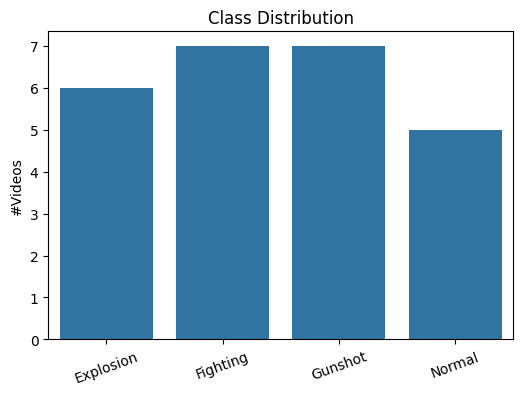

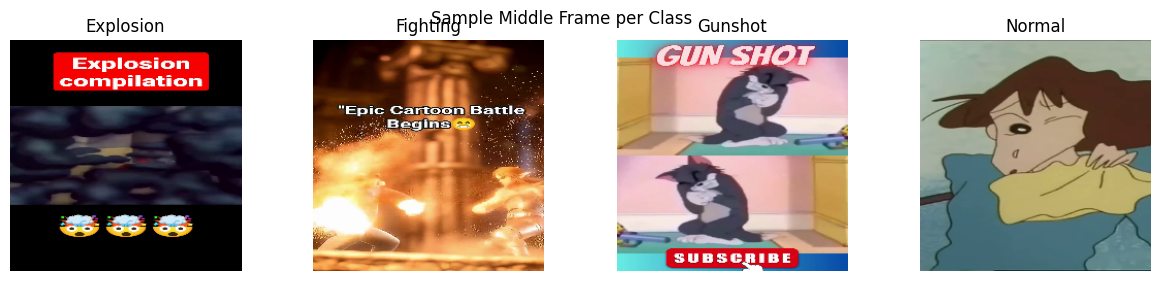

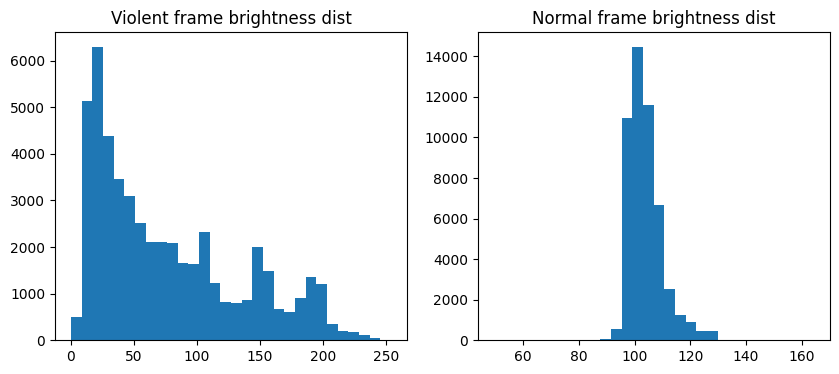

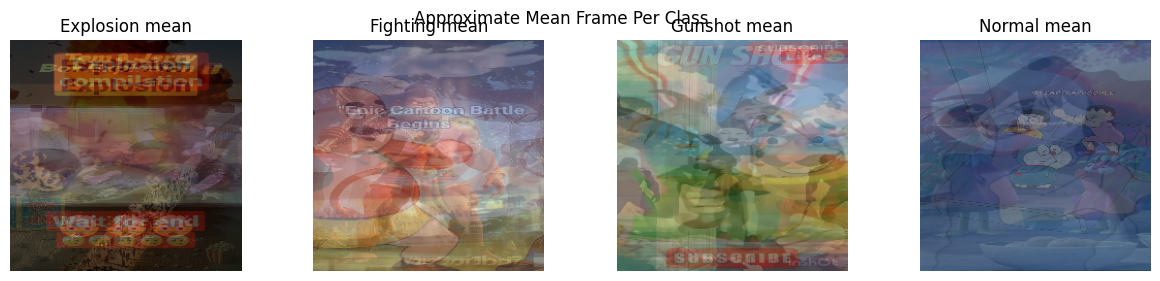

In [42]:
# 1. class distribution
counts = [np.sum(all_labels==i) for i in range(num_classes)]
plt.figure(figsize=(6,4))
sns.barplot(x=CLASS_NAMES, y=counts)
plt.title("Class Distribution")
plt.ylabel("#Videos")
plt.xticks(rotation=20)
plt.show()

# helper to grab random frame
def random_frame_from_class(cls_idx):
    idxs = np.where(all_labels==cls_idx)[0]
    if len(idxs) == 0: # Check if there are any samples for this class
        return None
    pick = random.choice(idxs)
    frame = all_videos[pick][SEQ_LEN//2]  # middle frame of sequence
    return frame

# 2. montage of sample frames per class
plt.figure(figsize=(15,3))
for i,cls in enumerate(CLASS_NAMES):
    plt.subplot(1,num_classes,i+1)
    img = random_frame_from_class(i)
    if img is not None: # Only show if a frame was successfully retrieved
        plt.imshow(img)
    plt.axis("off")
    plt.title(cls)
plt.suptitle("Sample Middle Frame per Class")
plt.show()

# 3. brightness hist compare (violence vs normal)
# Corrected indices: 0, 1, 2 are violent, 3 is normal
violent_idx = np.where(np.isin(all_labels, [0, 1, 2]))[0]
normal_idx  = np.where(all_labels==3)[0] # Corrected to index 3

v_frame = None
if len(violent_idx) > 0: # Check if there are violent samples
  v_frame = all_videos[random.choice(violent_idx)][SEQ_LEN//2]

n_frame = None
if len(normal_idx) > 0: # Check if there are normal samples
  n_frame = all_videos[random.choice(normal_idx)][SEQ_LEN//2]

if v_frame is not None and n_frame is not None: # Only plot if both frames were retrieved
  plt.figure(figsize=(10,4))
  plt.subplot(1,2,1); plt.hist(v_frame.mean(axis=2).flatten(), bins=30); plt.title("Violent frame brightness dist")
  plt.subplot(1,2,2); plt.hist(n_frame.mean(axis=2).flatten(), bins=30); plt.title("Normal frame brightness dist")
  plt.show()
else:
  print("Could not retrieve frames for brightness comparison (violent or normal class empty).")


# 4. per-class mean frame (coarse "prototype look")
plt.figure(figsize=(15,3))
for i,cls in enumerate(CLASS_NAMES):
    idxs = np.where(all_labels==i)[0]
    if len(idxs) == 0: # Skip if class is empty
        continue
    subset = np.random.choice(idxs, size=min(5,len(idxs)), replace=False)
    mean_img = np.mean([all_videos[s][SEQ_LEN//2] for s in subset], axis=0).astype(np.uint8)
    plt.subplot(1,num_classes,i+1)
    plt.imshow(mean_img)
    plt.axis("off")
    plt.title(cls+" mean")
plt.suptitle("Approximate Mean Frame Per Class")
plt.show()

In [47]:
def build_small_cnn_feature_extractor():
    inp = Input(shape=(IMG_SIZE,IMG_SIZE,3))
    # Conv block 1
    x = layers.Conv2D(64,(3,3),padding='same',activation='relu')(inp)
    x = layers.Conv2D(64,(3,3),padding='same',activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    # Conv block 2
    x = layers.Conv2D(128,(3,3),padding='same',activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    # Add GlobalAveragePooling2D to reduce dimensionality
    x = layers.GlobalAveragePooling2D()(x)
    # x = layers.Flatten()(x) # No longer need flatten after GlobalAveragePooling2D
    model = models.Model(inp,x,name="SmallCNN")
    return model

small_cnn = build_small_cnn_feature_extractor()
small_cnn.summary()

def extract_seq_features_cnn(x):
    # x: (batch, SEQ_LEN, H,W,3) -> (batch, SEQ_LEN, feat_dim)
    b, t = x.shape[0], x.shape[1]
    x_reshaped = x.reshape((-1, IMG_SIZE, IMG_SIZE,3))
    feats = small_cnn.predict(x_reshaped, verbose=0)
    feat_dim = feats.shape[1]
    feats = feats.reshape((b,t,feat_dim))
    return feats

# ResNet50 feature extractor
base_resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg',
                       input_shape=(IMG_SIZE,IMG_SIZE,3))
for layer in base_resnet.layers:
    layer.trainable = False  # start frozen, you can unfreeze later

def extract_seq_features_resnet(x):
    b, t = x.shape[0], x.shape[1]
    x_reshaped = x.reshape((-1, IMG_SIZE, IMG_SIZE,3))
    x_prep = resnet_preprocess(x_reshaped.astype(np.float32))
    feats = base_resnet.predict(x_prep, verbose=0)   # (b*t, 2048)
    feats = feats.reshape((b,t,feats.shape[1]))
    return feats

def extract_seq_features_rawpixels(x):
    # Flatten raw pixels per frame
    b, t = x.shape[0], x.shape[1]
    x_norm = (x.astype(np.float32)/255.0)
    feats = x_norm.reshape((b,t,-1))  # huge dim: 224*224*3
    return feats

Model: "SmallCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,576 (439.75 KB)

 Trainable params: 112,576 (439.75 KB)

 Non-trainable params: 0 (0.00 B)

**Exsisting model**

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_29             │ (None, 16, 401408)     │       112,576 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │   205,586,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,716,548 (784.75 MB)

 Trainable params: 205,716,548 (784.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.2798 - loss: 1.6545 - val_accuracy: 0.2500 - val_loss: 1.3966
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 472ms/step - accuracy: 0.1804 - loss: 1.4196 - val_accuracy: 0.2500 - val_loss: 1.3986
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.4346 - loss: 1.3896 - val_accuracy: 0.2500 - val_loss: 1.4329
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - accuracy: 0.3515 - loss: 1.3847 - val_accuracy: 0.2500 - val_loss: 1.4263


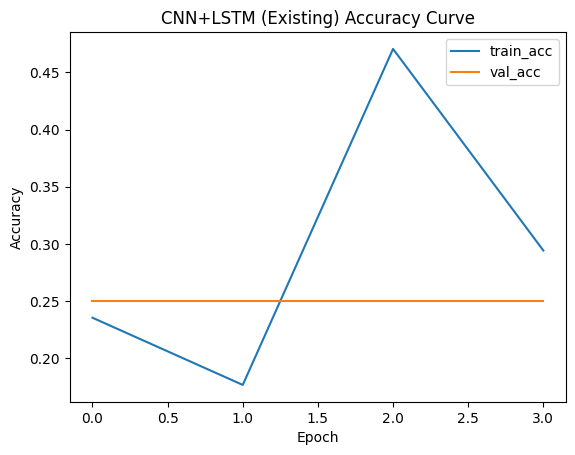

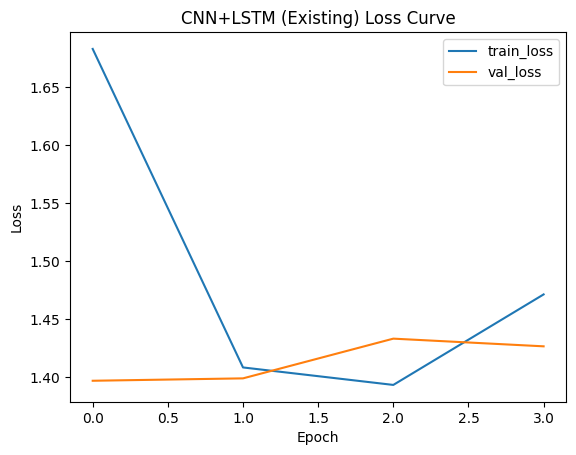

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
CNN+LSTM Accuracy: 25.00%
              precision    recall  f1-score   support

   Explosion       0.25      1.00      0.40         1
    Fighting       0.00      0.00      0.00         1
     Gunshot       0.00      0.00      0.00         1
      Normal       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


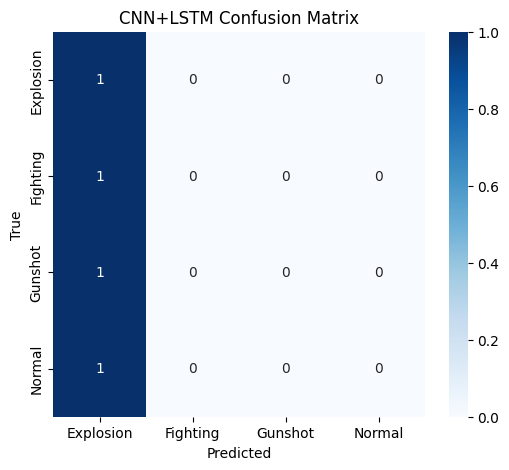

In [44]:
def build_cnn_lstm_model(num_classes):
    frame_input = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE,3))
    # per-frame CNN (TimeDistributed)
    cnn_backbone = build_small_cnn_feature_extractor()
    x = layers.TimeDistributed(cnn_backbone)(frame_input)  # (B,SEQ_LEN,feat_dim)
    # LSTM temporal modeling
    x = layers.LSTM(128)(x)
    # classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(frame_input, out, name="CNN_LSTM")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_lstm_model = build_cnn_lstm_model(num_classes)
cnn_lstm_model.summary()

history_cnn_lstm = cnn_lstm_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=20,
    batch_size=4,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)

plot_history(history_cnn_lstm, "CNN+LSTM (Existing)")
acc_cnn_lstm, cm_cnn_lstm = evaluate_and_report(cnn_lstm_model, X_test, y_test, name="CNN+LSTM")


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0615 - loss: 18.5032 - val_accuracy: 0.2500 - val_loss: 6.6430
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.2498 - loss: 9.0936 - val_accuracy: 0.2500 - val_loss: 2.8313
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.1075 - loss: 9.3265 - val_accuracy: 0.5000 - val_loss: 1.4695
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.2610 - loss: 4.6911 - val_accuracy: 0.5000 - val_loss: 1.4136
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.2388 - loss: 2.7942 - val_accuracy: 0.5000 - val_loss: 1.4110
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.1991 - loss: 4.2203 - val_accuracy: 0.7500 - val_loss: 0.9360
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.3316 - loss: 2.7697 - val_accuracy: 0.2500 - val_loss: 1.3608
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.1202 - loss: 4.3174 - val_accuracy: 0.2500 - val_loss: 

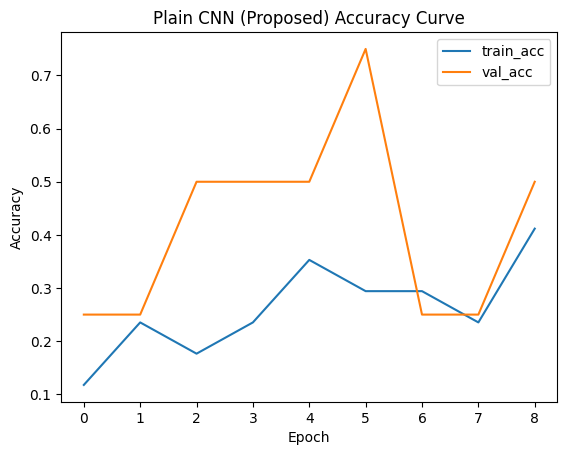

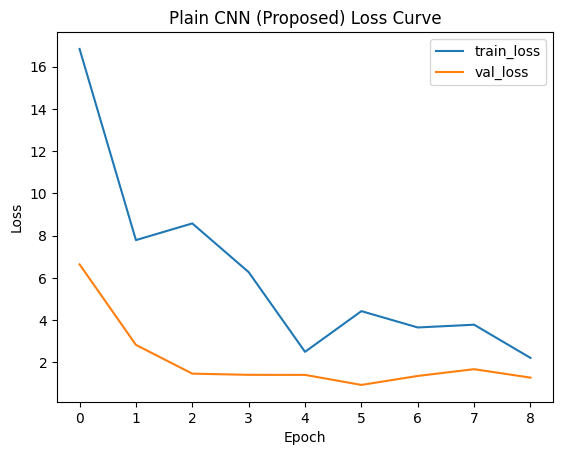

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plain CNN Accuracy: 25.00%
              precision    recall  f1-score   support

   Explosion       0.50      1.00      0.67         1
    Fighting       0.00      0.00      0.00         1
     Gunshot       0.00      0.00      0.00         1
      Normal       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.12      0.25      0.17         4
weighted avg       0.12      0.25      0.17         4



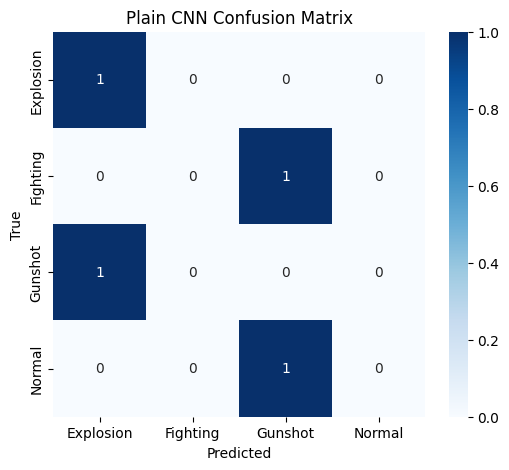

In [50]:
def build_cnn_avg_model(num_classes):
    frame_input = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE,3))
    cnn_backbone = build_small_cnn_feature_extractor()
    x = layers.TimeDistributed(cnn_backbone)(frame_input)  # (B,T,F)
    x = layers.GlobalAveragePooling1D()(x)  # average features over frames
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(frame_input, out, name="CNN_AvgPoolOverTime")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_avg_model = build_cnn_avg_model(num_classes)
history_cnn_avg = cnn_avg_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=20,
    batch_size=2,  # Reduced batch size
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)
plot_history(history_cnn_avg, "Plain CNN (Proposed)")
acc_cnn_avg, cm_cnn_avg = evaluate_and_report(cnn_avg_model, X_test, y_test, name="Plain CNN")

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 518ms/step - accuracy: 0.2151 - loss: 1.5862 - val_accuracy: 0.2500 - val_loss: 1.5711
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.5584 - loss: 1.3387 - val_accuracy: 0.2500 - val_loss: 1.4589
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.3076 - loss: 1.6516 - val_accuracy: 0.2500 - val_loss: 1.4818
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.1364 - loss: 1.6772 - val_accuracy: 0.2500 - val_loss: 1.4483
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.4150 - loss: 1.5046 - val_accuracy: 0.2500 - val_loss: 1.3595
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.3838 - loss: 1.4662 - val_accuracy: 0.2500 - val_loss: 1.4061
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.3803 - loss: 1.3941 - val_accuracy: 0.2500 - val_loss: 1.3540
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.2868 - loss: 1.3399 - val_accuracy: 0.2500 - val_loss:

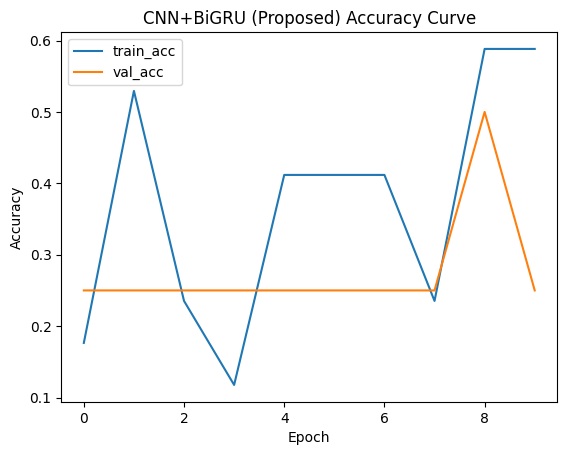

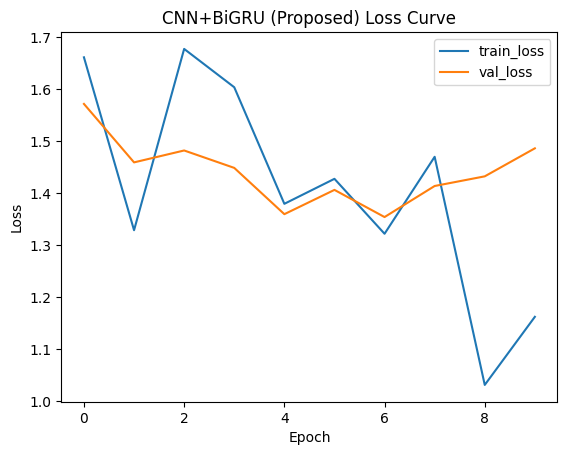

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step
CNN+BiGRU Accuracy: 75.00%
              precision    recall  f1-score   support

   Explosion       1.00      1.00      1.00         1
    Fighting       0.50      1.00      0.67         1
     Gunshot       1.00      1.00      1.00         1
      Normal       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


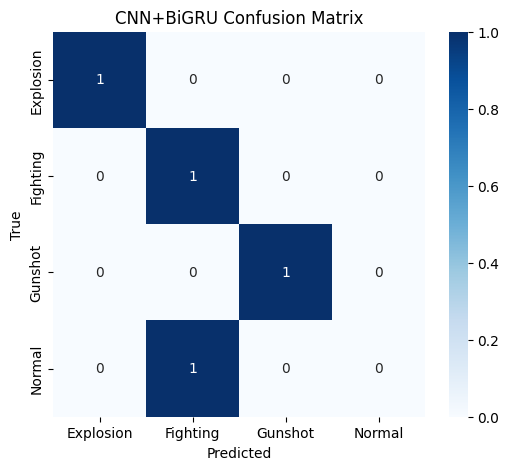

In [48]:
def build_cnn_bigru_model(num_classes):
    frame_input = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE,3))
    # Use the modified small_cnn_feature_extractor
    cnn_backbone = build_small_cnn_feature_extractor()
    x = layers.TimeDistributed(cnn_backbone)(frame_input)
    # The input to BiGRU is now the output of GlobalAveragePooling2D
    x = layers.Bidirectional(layers.GRU(128))(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(frame_input, out, name="CNN_BiGRU")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_bigru_model = build_cnn_bigru_model(num_classes)
history_cnn_bigru = cnn_bigru_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=20,
    batch_size=4,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)
plot_history(history_cnn_bigru, "CNN+BiGRU (Proposed)")
acc_cnn_bigru, cm_cnn_bigru = evaluate_and_report(cnn_bigru_model, X_test, y_test, name="CNN+BiGRU")

Model: "ResNet50_BiGRU_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_35             │ (None, 16, 2048)       │    23,587,712 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 512)            │     3,542,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,294,468 (104.12 MB)

 Trainable params: 3,706,756 (14.14 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.2507 - loss: 1.7384 - val_accuracy: 0.2500 - val_loss: 1.4217
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - accuracy: 0.3210 - loss: 1.6261 - val_accuracy: 0.2500 - val_loss: 1.4874
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step - accuracy: 0.3716 - loss: 1.5803 - val_accuracy: 0.2500 - val_loss: 1.4739
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step - accuracy: 0.7918 - loss: 0.8486 - val_accuracy: 0.2500 - val_loss: 1.4488


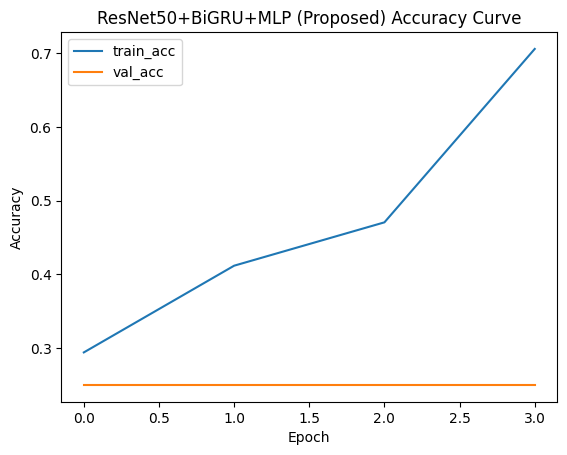

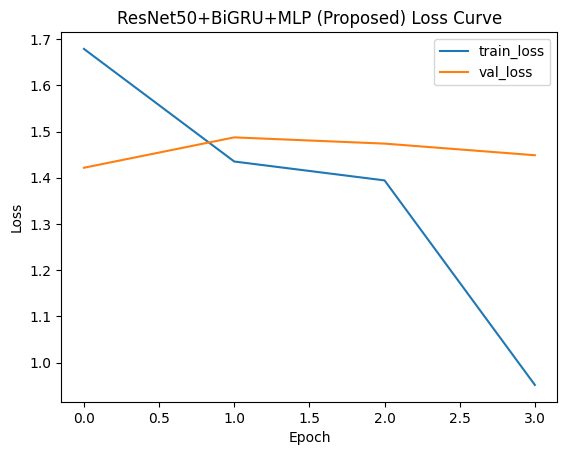

1/1 ━━━━━━━━━━━━━━━━━━━━ 35s 35s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ResNet50+BiGRU+MLP Accuracy: 50.00%
              precision    recall  f1-score   support

   Explosion       0.00      0.00      0.00         1
    Fighting       0.33      1.00      0.50         1
     Gunshot       1.00      1.00      1.00         1
      Normal       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.33      0.50      0.38         4
weighted avg       0.33      0.50      0.38         4



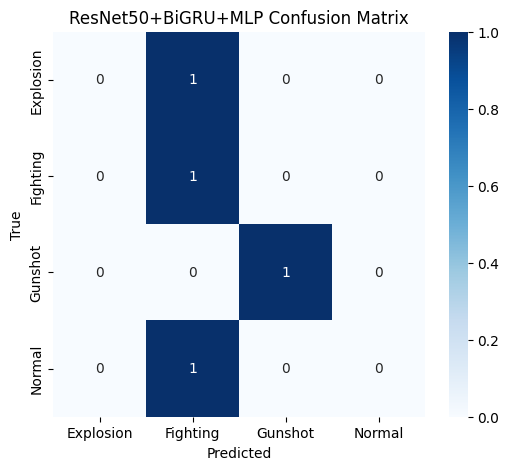

In [51]:
def build_resnet_bigru_mlp(num_classes):
    frame_input = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE,3))

    # TimeDistributed ResNet50 (frozen)
    def resnet_feature_block():
        inp = Input(shape=(IMG_SIZE,IMG_SIZE,3))
        x = base_resnet(inp)
        return models.Model(inp,x,name="ResNet50_Feats")

    res_block = resnet_feature_block()
    x = layers.TimeDistributed(res_block)(frame_input)  # (B,T,2048)

    # temporal modeling
    x = layers.Bidirectional(layers.GRU(256, return_sequences=False))(x)

    # 2-layer MLP head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(frame_input, out, name="ResNet50_BiGRU_MLP")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

resnet_bigru_mlp_model = build_resnet_bigru_mlp(num_classes)
resnet_bigru_mlp_model.summary()

history_resnet_bigru_mlp = resnet_bigru_mlp_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=20,
    batch_size=2,  # memory heavy, so smaller batch
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)
plot_history(history_resnet_bigru_mlp, "ResNet50+BiGRU+MLP (Proposed)")
acc_resnet_bigru_mlp, cm_resnet_bigru_mlp = evaluate_and_report(
    resnet_bigru_mlp_model, X_test, y_test, name="ResNet50+BiGRU+MLP")


Model: "MLP_only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,203,204 (294.51 MB)

 Trainable params: 77,203,204 (294.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3502 - loss: 7.0701 - val_accuracy: 0.2500 - val_loss: 4.0488
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3640 - loss: 9.0268 - val_accuracy: 0.2500 - val_loss: 8.0925
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3189 - loss: 16.2761 - val_accuracy: 0.2500 - val_loss: 19.3640
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1213 - loss: 23.0114 - val_accuracy: 0.2500 - val_loss: 23.6327


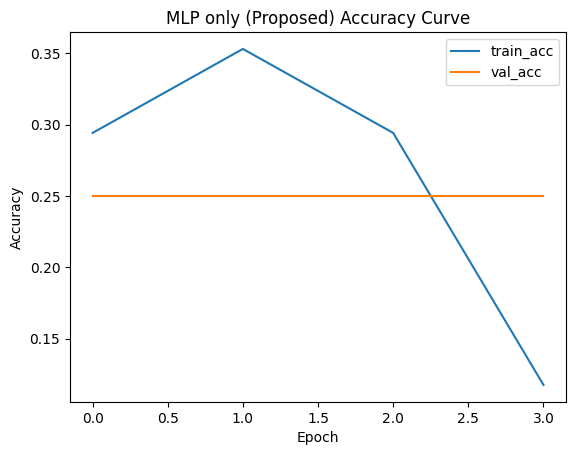

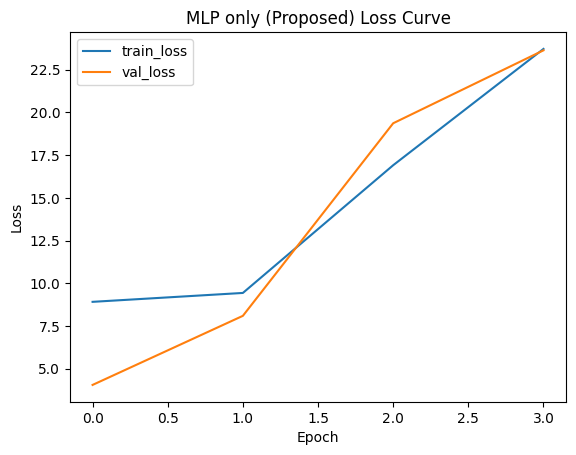

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
MLP only Accuracy: 50.00%
              precision    recall  f1-score   support

   Explosion       1.00      1.00      1.00         1
    Fighting       0.33      1.00      0.50         1
     Gunshot       0.00      0.00      0.00         1
      Normal       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.33      0.50      0.38         4
weighted avg       0.33      0.50      0.38         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


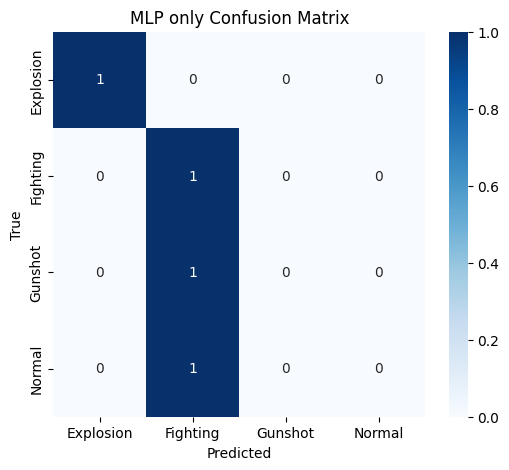

In [52]:
def build_mlp_only_model(num_classes, input_dim):
    inp = Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(inp)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp,out,name="MLP_only")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# build train tensors for MLP
X_train_flat = extract_seq_features_rawpixels(X_train).mean(axis=1)  # (B, feat_dim)
X_val_flat   = extract_seq_features_rawpixels(X_val).mean(axis=1)
X_test_flat  = extract_seq_features_rawpixels(X_test).mean(axis=1)

mlp_model = build_mlp_only_model(num_classes, X_train_flat.shape[1])
mlp_model.summary()

history_mlp = mlp_model.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_val_flat,y_val_cat),
    epochs=20,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)
plot_history(history_mlp, "MLP only (Proposed)")
acc_mlp, cm_mlp = evaluate_and_report(mlp_model, X_test_flat, y_test, name="MLP only")


**Fusion model (combine CNN, Bi-GRU, ResNet50, MLP-style branch)**

Model: "Fusion_All"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 16, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 16, 224,   │          0 │ input_layer_24[0… │
│                     │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_36 │ (None, 16, 128)   │    112,576 │ input_layer_24[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_37 │ (None, 16, 2048)  │ 23,587,712 │ input_layer_24[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16,        │          0 │ lambda[0][0]      │
│                     │ 150528)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 256)       │    198,144 │ time_distributed… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 256)       │  1,672,704 │ time_distributed… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 150528)    │          0 │ reshape[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 151040)    │          0 │ bidirectional_10… │
│ (Concatenate)       │                   │            │ bidirectional_11… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 512)       │ 77,332,992 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 512)       │          0 │ dense_34[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 256)       │    131,328 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 256)       │          0 │ dense_35[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 4)         │      1,028 │ dropout_26[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 103,036,484 (393.05 MB)

 Trainable params: 79,448,772 (303.07 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 147s 5s/step - accuracy: 0.1230 - loss: 6.7970 - val_accuracy: 0.2500 - val_loss: 12.8961
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 559ms/step - accuracy: 0.2052 - loss: 16.7551 - val_accuracy: 0.2500 - val_loss: 11.0308
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 550ms/step - accuracy: 0.1536 - loss: 24.7264 - val_accuracy: 0.2500 - val_loss: 9.8727
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 586ms/step - accuracy: 0.2696 - loss: 21.8190 - val_accuracy: 0.5000 - val_loss: 6.5949
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 470ms/step - accuracy: 0.3963 - loss: 16.8060 - val_accuracy: 0.2500 - val_loss: 7.5618
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 489ms/step - accuracy: 0.1989 - loss: 24.3504 - val_accuracy: 0.5000 - val_loss: 8.6140
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 472ms/step - accuracy: 0.3537 - loss: 13.6811 - val_accuracy: 0.2500 - val_loss: 17.9498


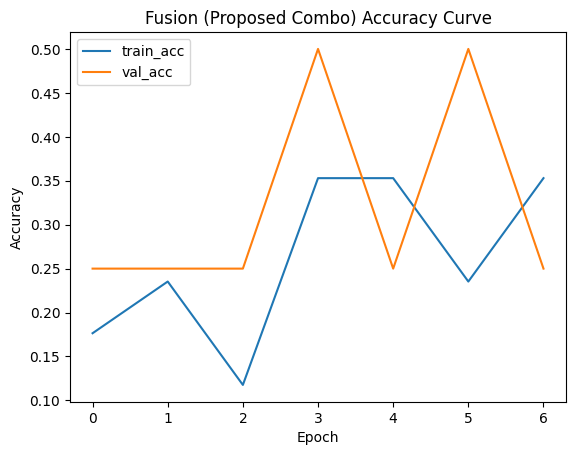

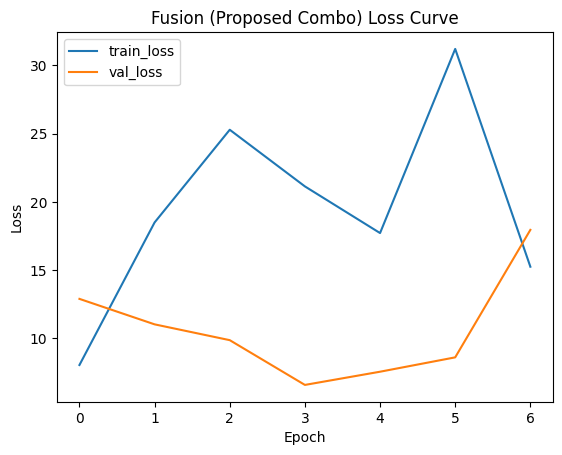

1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step
Fusion Accuracy: 50.00%
              precision    recall  f1-score   support

   Explosion       1.00      1.00      1.00         1
    Fighting       0.00      0.00      0.00         1
     Gunshot       0.33      1.00      0.50         1
      Normal       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.33      0.50      0.38         4
weighted avg       0.33      0.50      0.38         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


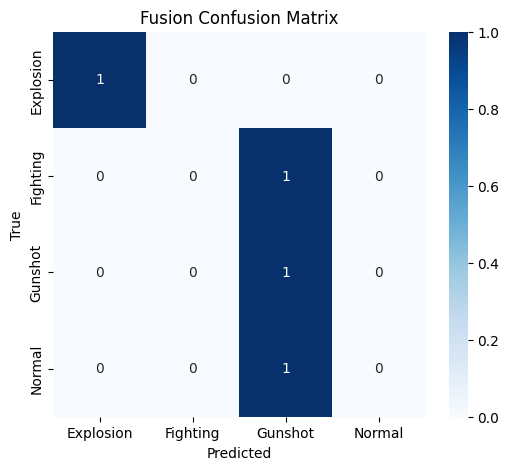

In [53]:
def build_fusion_model(num_classes):
    frame_input = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE,3))

    # Branch A: small CNN + BiGRU
    small_cnn_backbone = build_small_cnn_feature_extractor()
    a = layers.TimeDistributed(small_cnn_backbone)(frame_input)     # (B,T,F1)
    a = layers.Bidirectional(layers.GRU(128))(a)                    # (B,256)

    # Branch B: ResNet50 + BiGRU
    def res_block_model():
        inp = Input(shape=(IMG_SIZE,IMG_SIZE,3))
        x = base_resnet(inp)
        return models.Model(inp,x,name="ResNet50_Feats_Fusion")

    res_block = res_block_model()
    b = layers.TimeDistributed(res_block)(frame_input)              # (B,T,2048)
    b = layers.Bidirectional(layers.GRU(128))(b)                    # (B,256)

    # Branch C: raw pixels avg
    c = layers.Lambda(lambda z: tf.cast(z,tf.float32)/255.0)(frame_input) # (B,T,H,W,3) float
    c = layers.Reshape((SEQ_LEN, IMG_SIZE*IMG_SIZE*3))(c)                  # flatten per frame
    c = layers.GlobalAveragePooling1D()(c)                                  # (B,feat_dim_avg)

    # Concatenate
    fused = layers.Concatenate()([a,b,c])

    # MLP head
    x = layers.Dense(512, activation='relu')(fused)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(frame_input, out, name="Fusion_All")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

fusion_model = build_fusion_model(num_classes)
fusion_model.summary()

history_fusion = fusion_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=20,
    batch_size=2,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)
plot_history(history_fusion, "Fusion (Proposed Combo)")
acc_fusion, cm_fusion = evaluate_and_report(fusion_model, X_test, y_test, name="Fusion")


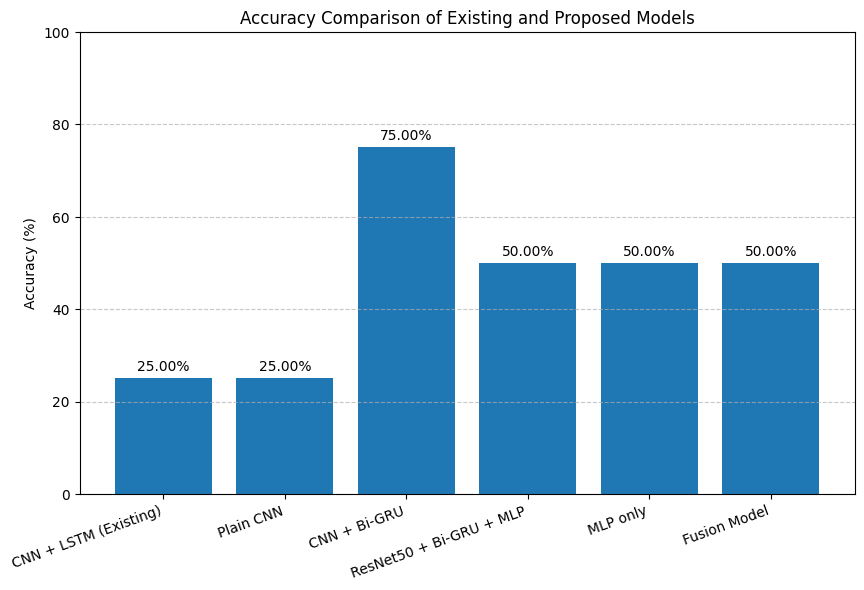

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Fill in your measured test accuracies here
# (Replace these with your actual printed results)
acc_results = {
    "CNN + LSTM (Existing)": acc_cnn_lstm,
    "Plain CNN": acc_cnn_avg,
    "CNN + Bi-GRU": acc_cnn_bigru,
    "ResNet50 + Bi-GRU + MLP": acc_resnet_bigru_mlp,
    "MLP only": acc_mlp,
    "Fusion Model": acc_fusion
}

# Convert to DataFrame
acc_df = pd.DataFrame(list(acc_results.items()), columns=["Model", "Accuracy"])
acc_df["Accuracy (%)"] = acc_df["Accuracy"] * 100

# Plot bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy (%)"])
plt.title("Accuracy Comparison of Existing and Proposed Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1,
             f"{yval:.2f}%", ha='center', va='bottom', fontsize=10)

plt.show()


In [56]:
from IPython.display import display

# Sort table by accuracy (descending)
acc_df = acc_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(acc_df.style.set_caption("Model Accuracy Comparison")
        .background_gradient(subset=["Accuracy (%)"], cmap="YlGn")
        .format({"Accuracy": "{:.4f}", "Accuracy (%)": "{:.2f}%"}))


,Model,Accuracy,Accuracy (%)
0,CNN + Bi-GRU,0.7500,75.00%
1,ResNet50 + Bi-GRU + MLP,0.5000,50.00%
2,MLP only,0.5000,50.00%
3,Fusion Model,0.5000,50.00%
4,Plain CNN,0.2500,25.00%
5,CNN + LSTM (Existing),0.2500,25.00%


In [57]:
save_path = "/content/drive/MyDrive/cartoon/cnn_bigru_model.h5"  # change path if you want
cnn_bigru_model.save(save_path)
print("Model saved to:", save_path)


Model saved to: /content/drive/MyDrive/cartoon/cnn_bigru_model.h5


[INFO] Model loaded.
[INFO] Extracted 16 frames from video.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
Video: /content/drive/MyDrive/cartoon/dataset/Fighting/7.mp4
Predicted class: Fighting
Confidence: 28.71%
Class probabilities:
   Explosion: 28.15%
    Fighting: 28.71%
     Gunshot: 20.19%
      Normal: 22.96%


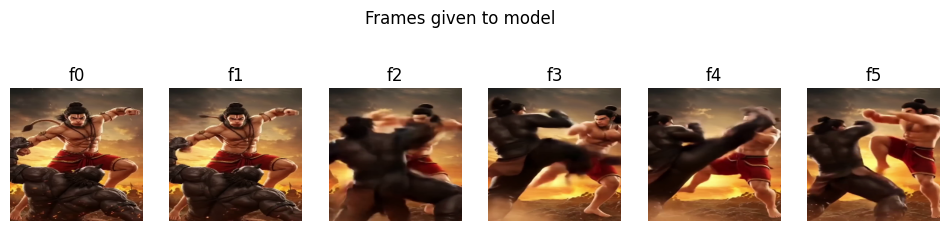

In [62]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==== USER INPUTS (edit these two paths) ====
MODEL_PATH = "/content/drive/MyDrive/cartoon/cnn_bigru_model.h5"  # e.g. "/content/drive/MyDrive/cnn_bigru_model.h5"
TEST_VIDEO_PATH = "/content/drive/MyDrive/cartoon/dataset/Fighting/7.mp4"
# ===========================================

# constants (must match training)
CLASS_NAMES = ["Explosion","Fighting","Gunshot","Normal"]
IMG_SIZE = 224
SEQ_LEN = 16

def load_video_frames_for_inference(path, seq_len=SEQ_LEN, img_size=IMG_SIZE):
    """
    Extracts seq_len frames uniformly from a video, resizes to img_size x img_size,
    returns np.array shaped (1, seq_len, img_size, img_size, 3) ready for model.predict().
    Also returns the sampled frames list (for optional visualization).
    """
    cap = cv2.VideoCapture(path)
    frames = []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total == 0:
        cap.release()
        raise ValueError(f"[ERROR] Could not read frames from video: {path}")

    # choose evenly spaced indices
    idxs = np.linspace(0, total-1, seq_len).astype(int)

    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, (img_size, img_size))
            frames.append(frame_resized)

    cap.release()

    # pad if short
    if len(frames) < seq_len:
        if len(frames) == 0:
            raise ValueError("[ERROR] No frames extracted after reading video.")
        while len(frames) < seq_len:
            frames.append(frames[-1])

    clip = np.array(frames[:seq_len], dtype=np.uint8)  # (SEQ_LEN,224,224,3)
    clip_batch = np.expand_dims(clip, axis=0)          # (1,SEQ_LEN,224,224,3)
    return clip_batch, frames

def predict_video(model_path, video_path):
    # load model
    model = load_model(model_path)
    print("[INFO] Model loaded.")

    # prep clip
    clip_batch, sampled_frames = load_video_frames_for_inference(video_path)
    print(f"[INFO] Extracted {clip_batch.shape[1]} frames from video.")

    # inference
    probs = model.predict(clip_batch)  # (1,num_classes)
    probs = probs[0]

    pred_idx = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx]

    # print results
    print("========================================")
    print("Video:", video_path)
    print("Predicted class:", pred_class)
    print(f"Confidence: {confidence*100:.2f}%")
    print("Class probabilities:")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:>10s}: {probs[i]*100:.2f}%")
    print("========================================")

    # optional: quick viz of first few sampled frames
    n_show = min(6, len(sampled_frames))
    plt.figure(figsize=(12,3))
    for i in range(n_show):
        plt.subplot(1,n_show,i+1)
        plt.imshow(sampled_frames[i])
        plt.axis("off")
        plt.title(f"f{i}")
    plt.suptitle("Frames given to model")
    plt.show()

# ==== RUN ====
predict_video(MODEL_PATH, TEST_VIDEO_PATH)


In [61]:
!python

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> 
KeyboardInterrupt
>>> 
KeyboardInterrupt
>>> ^C
